# Space Reliability Index + Explainability

In [1]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

pd.set_option('display.max_columns', None)

## Configurations

In [2]:
RAW_CSV_PATH = "burn_in_dataset.csv"
ANOMALY_RESULTS_PATH = "anomaly_results.csv"
ANOMALY_SHAP_BUNDLE_PATH = "anomaly_shap_bundle.joblib"
DRIFT_MODEL_PATH = "drift_prediction_models.joblib"
SPLIT_PATH = "component_split.csv"

METRICS = ['Leakage', 'Resistance', 'Vth']
CHECKPOINTS = ['0h', '24h', '96h', '168h']

ABSOLUTE_FAIL_RISK_FLOOR = 65.0

SLOPE_REJECT_RISK_FLOOR = 65.0

TARGET_RECALL = 0.98

## Load everything

In [3]:
df = pd.read_csv(RAW_CSV_PATH)
anomaly = pd.read_csv(ANOMALY_RESULTS_PATH)
bundle = joblib.load(DRIFT_MODEL_PATH)
anomaly_shap_bundle = joblib.load(ANOMALY_SHAP_BUNDLE_PATH)
split = pd.read_csv(SPLIT_PATH)

print(df.shape, 'raw rows')
print(anomaly.shape, 'anomaly results rows')

missing_from_raw = set(anomaly['Component_ID']) - set(df['Component_ID'])
missing_from_anomaly = set(df['Component_ID']) - set(anomaly['Component_ID'])
print(f'{len(missing_from_raw)} anomaly rows have no match in raw data; '
      f'{len(missing_from_anomaly)} raw rows have no match in anomaly results')

if 'safety_slope' not in bundle:
    raise KeyError("drift_prediction_models.joblib has no 'safety_slope' key - re-run the v5.1 "
                    "drift-prediction notebook first so both modules share the same thresholds.")
safety_slope = bundle['safety_slope']
anomaly.head()

(10000, 25) raw rows
(10000, 14) anomaly results rows
0 anomaly rows have no match in raw data; 0 raw rows have no match in anomaly results


,Component_ID,Batch_ID,Part_Type,Absolute_Spec_Fail,Lot_Relative_Score,Worst_Lot_Zscore,Multivariate_Score,Drift_Score,Anomaly_Risk_Score,QA_Decision,Label,Traditional_Test_Result,split,SHAP_Top_Anomaly_Features
0,C501,ISRO-SCL-250421-16,MOSFET,0,12.6,1.01,10.3,3.0,7.7,PASS,Safe,Pass,train,NaN
1,C502,ISRO-SCL-250224-08,MOSFET,0,21.0,1.68,10.2,25.7,20.2,HOLD,Borderline,Pass,train,NaN
2,C503,ISRO-SCL-250414-15,Digital Logic IC,0,100.0,9.02,38.6,7.0,41.5,HOLD,Safe,Pass,train,NaN
3,C504,ISRO-SCL-250113-02,MOSFET,0,16.5,1.32,22.6,24.1,21.6,HOLD,Borderline,Pass,train,NaN
4,C506,ISRO-SCL-250428-17,Voltage Regulator IC,0,17.1,1.37,37.5,18.6,23.2,HOLD,Safe,Pass,train,NaN


## Re-run Module B's feature pipeline

In [4]:
feature_cols_raw = bundle['feature_cols_raw']

reading_cols = [f'{m}_{cp}' for m in METRICS for cp in CHECKPOINTS]
for col in reading_cols:
    df.loc[df[col] < 0, col] = np.nan

for cp in CHECKPOINTS:
    df[f'Timestamp_{cp}'] = pd.to_datetime(df[f'Timestamp_{cp}'], format='ISO8601')
df['elapsed_24h'] = (df['Timestamp_24h'] - df['Timestamp_0h']).dt.total_seconds() / 3600
df['elapsed_168h'] = (df['Timestamp_168h'] - df['Timestamp_0h']).dt.total_seconds() / 3600   # FIX (v3): needed for the safety-slope check

df.loc[:, feature_cols_raw] = bundle['imputer'].transform(df[feature_cols_raw])

df['Leakage_slope'] = (df['Leakage_24h'] - df['Leakage_0h']) / df['elapsed_24h']
df['Resistance_slope'] = (df['Resistance_24h'] - df['Resistance_0h']) / df['elapsed_24h']
df['Vth_slope'] = (df['Vth_24h'] - df['Vth_0h']) / df['elapsed_24h']

feature_cols_num = feature_cols_raw + ['Stress_Level', 'elapsed_24h', 'Leakage_slope', 'Resistance_slope', 'Vth_slope']
X = pd.get_dummies(df[feature_cols_num + ['Proxy_Stress', 'Part_Type']], columns=['Proxy_Stress', 'Part_Type'])
X = X.reindex(columns=bundle['feature_columns'], fill_value=0)
X.shape

(10000, 18)

In [5]:
rf_pred = bundle['rf'].predict(X)
gb_pred = bundle['gb'].predict(X)
stacked_raw = bundle['meta_model'].predict(np.hstack([rf_pred, gb_pred]))
lower_raw = bundle['quantile_lower'].predict(X)
upper_raw = bundle['quantile_upper'].predict(X)

lower_raw, upper_raw = np.minimum(lower_raw, upper_raw), np.maximum(lower_raw, upper_raw)

def reconstruct(raw):
    out = pd.DataFrame(index=df.index)
    out['Leakage_168h'] = np.expm1(raw[:, 1])
    out['Resistance_168h'] = df['Resistance_24h'].values + raw[:, 3]
    out['Vth_168h'] = df['Vth_24h'].values + raw[:, 5]
    return out

point, lower, upper = reconstruct(stacked_raw), reconstruct(lower_raw), reconstruct(upper_raw)
rf_point, gb_point = reconstruct(rf_pred), reconstruct(gb_pred)

df['Pred_Leakage_168h'] = point['Leakage_168h']
df['Pred_Resistance_168h'] = point['Resistance_168h']
df['Pred_Vth_168h'] = point['Vth_168h']
df['Interval_Width_Leakage'] = (upper['Leakage_168h'] - lower['Leakage_168h']).clip(lower=0)
df['Interval_Width_Resistance'] = (upper['Resistance_168h'] - lower['Resistance_168h']).clip(lower=0)
df['Interval_Width_Vth'] = (upper['Vth_168h'] - lower['Vth_168h']).clip(lower=0)

# RF-vs-GB disagreement
df['Disagreement_Leakage'] = (rf_point['Leakage_168h'] - gb_point['Leakage_168h']).abs()
df['Disagreement_Resistance'] = (rf_point['Resistance_168h'] - gb_point['Resistance_168h']).abs()
df['Disagreement_Vth'] = (rf_point['Vth_168h'] - gb_point['Vth_168h']).abs()

df[['Pred_Leakage_168h','Pred_Resistance_168h','Pred_Vth_168h']].describe()

,Pred_Leakage_168h,Pred_Resistance_168h,Pred_Vth_168h
count,10000.000000,10000.000000,10000.000000
mean,1.252956,104.013558,1.228236
std,0.918247,5.972193,0.095051
min,0.204008,91.007204,0.820375
25%,0.637832,99.303102,1.153743
50%,1.051699,103.971899,1.229191
75%,1.552506,108.530534,1.304401
max,6.210807,129.931516,1.447077


## Turn predictions into three 0-100 scores

In [6]:
df = df.merge(split[['Component_ID','split']], on='Component_ID')
fit_mask = df['split'].isin(['train','val'])   # normalization bounds never see `test`

pred_leak_drift = ((df['Pred_Leakage_168h'] - df['Leakage_24h']) / df['Leakage_24h'].abs()).abs()
pred_res_drift = ((df['Pred_Resistance_168h'] - df['Resistance_24h']) / df['Resistance_24h'].abs()).abs()
pred_vth_drift = ((df['Pred_Vth_168h'] - df['Vth_24h']) / df['Vth_24h'].abs()).abs()

df['Predicted_Drift_Leakage'] = pred_leak_drift
df['Predicted_Drift_Resistance'] = pred_res_drift
df['Predicted_Drift_Vth'] = pred_vth_drift
df['Predicted_Drift_Severity_raw'] = pd.concat([pred_leak_drift, pred_res_drift, pred_vth_drift], axis=1).max(axis=1)

bound = df.loc[fit_mask, 'Predicted_Drift_Severity_raw'].quantile(0.99)
df['Predicted_Drift_Score'] = (df['Predicted_Drift_Severity_raw'].clip(upper=bound) / max(bound, 1e-9) * 100).clip(0, 100)

iw = df[['Interval_Width_Leakage', 'Interval_Width_Resistance', 'Interval_Width_Vth']]
iw_bounds = iw[fit_mask].quantile(0.99).clip(lower=1e-9)
aleatoric = ((iw / iw_bounds).clip(upper=1.5).max(axis=1) * 100).clip(0, 100)

dis = df[['Disagreement_Leakage', 'Disagreement_Resistance', 'Disagreement_Vth']]
dis_bounds = dis[fit_mask].quantile(0.99).clip(lower=1e-9)
epistemic = ((dis / dis_bounds).clip(upper=1.5).max(axis=1) * 100).clip(0, 100)

df['Uncertainty_Score'] = (0.6 * aleatoric + 0.4 * epistemic).clip(0, 100).round(1)

def _drift_rate(v24, v168, elapsed24, elapsed168):
    return (v168 - v24) / (elapsed168 - elapsed24)

slope_flag = pd.Series(False, index=df.index)
for m in METRICS:
    rate = _drift_rate(df[f'{m}_24h'], df[f'Pred_{m}_168h'], df['elapsed_24h'], df['elapsed_168h']).abs()
    slope_flag |= (rate > safety_slope[m])
df['Slope_Reject_Flag'] = slope_flag

df[['Predicted_Drift_Score', 'Uncertainty_Score']].describe()

,Predicted_Drift_Score,Uncertainty_Score
count,10000.000000,10000.000000
mean,28.063284,28.959940
std,20.251026,19.201438
min,0.583773,9.000000
25%,13.465106,16.600000
50%,21.594306,21.400000
75%,36.291602,31.800000
max,100.000000,100.000000


## Combine with Module A

In [7]:
merged = anomaly.merge(
    df[['Component_ID', 'Predicted_Drift_Score', 'Uncertainty_Score', 'Proxy_Stress', 'Slope_Reject_Flag',
        'Predicted_Drift_Leakage', 'Predicted_Drift_Resistance', 'Predicted_Drift_Vth',
        'Leakage_0h', 'Leakage_24h', 'Resistance_0h', 'Resistance_24h', 'Vth_0h', 'Vth_24h']],
    on='Component_ID', how='inner',
)
print(f'{len(merged)} components matched between the two modules')
merged.head()

10000 components matched between the two modules


,Component_ID,Batch_ID,Part_Type,Absolute_Spec_Fail,Lot_Relative_Score,Worst_Lot_Zscore,Multivariate_Score,Drift_Score,Anomaly_Risk_Score,QA_Decision,Label,Traditional_Test_Result,split,SHAP_Top_Anomaly_Features,Predicted_Drift_Score,Uncertainty_Score,Proxy_Stress,Slope_Reject_Flag,Predicted_Drift_Leakage,Predicted_Drift_Resistance,Predicted_Drift_Vth,Leakage_0h,Leakage_24h,Resistance_0h,Resistance_24h,Vth_0h,Vth_24h
0,C501,ISRO-SCL-250421-16,MOSFET,0,12.6,1.01,10.3,3.0,7.7,PASS,Safe,Pass,train,NaN,7.668001,16.3,Cycling-Medium,False,0.203846,0.008746,0.003822,0.905,0.959,97.63,98.21,1.228,1.230
1,C502,ISRO-SCL-250224-08,MOSFET,0,21.0,1.68,10.2,25.7,20.2,HOLD,Borderline,Pass,train,NaN,33.096699,34.4,Radiation-Low,False,0.879844,0.027365,0.031706,0.456,0.687,104.33,104.95,1.309,1.286
2,C503,ISRO-SCL-250414-15,Digital Logic IC,0,100.0,9.02,38.6,7.0,41.5,HOLD,Safe,Pass,train,NaN,10.839862,80.1,Cycling-Medium,True,0.288167,0.017387,0.061443,0.895,1.019,107.58,107.97,1.183,1.258
3,C504,ISRO-SCL-250113-02,MOSFET,0,16.5,1.32,22.6,24.1,21.6,HOLD,Borderline,Pass,train,NaN,9.404891,24.6,Cycling-Medium,False,0.250020,0.011798,0.010063,0.151,0.223,107.52,108.01,1.382,1.380
4,C506,ISRO-SCL-250428-17,Voltage Regulator IC,0,17.1,1.37,37.5,18.6,23.2,HOLD,Safe,Pass,train,NaN,24.202343,22.2,Radiation-Low,False,0.643396,0.017669,0.020454,0.286,0.391,113.03,114.44,1.419,1.412


## Tune weights + tier boundaries on `val` for a target RECALL, not just AUC


In [8]:
val_mask = merged['split'] == 'val'
label_val = merged.loc[val_mask, 'Label'].values
anomaly_v = merged.loc[val_mask, 'Anomaly_Risk_Score'].values
drift_v = merged.loc[val_mask, 'Predicted_Drift_Score'].values
unc_v = merged.loc[val_mask, 'Uncertainty_Score'].values
absfail_v = merged.loc[val_mask, 'Absolute_Spec_Fail'].values
slopeflag_v = merged.loc[val_mask, 'Slope_Reject_Flag'].values

def _floor(combined):
    combined = np.where(absfail_v == 1, np.maximum(combined, ABSOLUTE_FAIL_RISK_FLOOR), combined)
    combined = np.where(slopeflag_v, np.maximum(combined, SLOPE_REJECT_RISK_FLOOR), combined)
    return combined

def threshold_for_recall(combined, label, target_recall):
    fail_mask = (label == 'Fail')
    n_fail = int(fail_mask.sum())
    if n_fail == 0:
        return None
    order = np.argsort(-combined)
    caught = 0
    for idx in order:
        if fail_mask[idx]:
            caught += 1
        if caught / n_fail >= target_recall:
            thr = combined[idx]
            flagged = combined >= thr
            recall = float((flagged & fail_mask).sum()) / n_fail
            safe_mask = (label == 'Safe')
            fa = float((flagged & safe_mask).sum()) / max(int(safe_mask.sum()), 1)
            return float(thr), recall, fa
    return None

rng = np.random.RandomState(0)
best = None
for _ in range(500):
    w = rng.dirichlet([2, 2, 1])
    combined = _floor(w[0]*anomaly_v + w[1]*drift_v + w[2]*unc_v)
    result = threshold_for_recall(combined, label_val, TARGET_RECALL)
    if result is None:
        continue
    thr_borderline, recall, fa = result
    auc = roc_auc_score((label_val == 'Fail').astype(int), combined)
    key = (fa, -auc)
    if best is None or key < best[0]:
        best = (key, w, thr_borderline, recall, fa, auc)

if best is None:
    raise RuntimeError(
        f'No weight combination reached {TARGET_RECALL:.0%} recall on val Fail cases - '
        'lower TARGET_RECALL or revisit the upstream signals before shipping this tier.'
    )

_, best_w, thr_borderline, achieved_recall, achieved_fa, best_auc = best
tot = best_w.sum()
WEIGHT_ANOMALY, WEIGHT_PREDICTED_DRIFT, WEIGHT_UNCERTAINTY = [round(float(x/tot), 3) for x in best_w]
print('tuned weights -> anomaly:', WEIGHT_ANOMALY, ' drift:', WEIGHT_PREDICTED_DRIFT, ' uncertainty:', WEIGHT_UNCERTAINTY)
print(f'-> {achieved_recall:.1%} recall on val Fail via Borderline/High-Risk, at {achieved_fa:.1%} false-alarm rate '
      f'(AUC={best_auc:.4f}, reported for context only)')

combined_v = _floor(WEIGHT_ANOMALY*anomaly_v + WEIGHT_PREDICTED_DRIFT*drift_v + WEIGHT_UNCERTAINTY*unc_v)
safe_scores_v = combined_v[label_val == 'Safe']
RISK_SAFE_MAX = min(round(float(np.percentile(safe_scores_v, 80)), 1), round(thr_borderline - 0.1, 1))
RISK_BORDERLINE_MAX = max(round(float(np.percentile(safe_scores_v, 95)), 1), round(thr_borderline, 1))
print('tuned tier boundaries -> Safe <', RISK_SAFE_MAX, ' Borderline <', RISK_BORDERLINE_MAX)
print(f'NOTE: Borderline cut is anchored to the {TARGET_RECALL:.0%}-recall threshold on val; Safe cut is the')
print('80th percentile of val Safe scores (softer early-warning tier), clipped below the recall anchor.')

tuned weights -> anomaly: 0.278  drift: 0.67  uncertainty: 0.052
-> 98.1% recall on val Fail via Borderline/High-Risk, at 27.5% false-alarm rate (AUC=0.9091, reported for context only)
tuned tier boundaries -> Safe < 21.8  Borderline < 65.0
NOTE: Borderline cut is anchored to the 98%-recall threshold on val; Safe cut is the
80th percentile of val Safe scores (softer early-warning tier), clipped below the recall anchor.


In [9]:
merged['Space_Risk_Score'] = (
    WEIGHT_ANOMALY * merged['Anomaly_Risk_Score']
    + WEIGHT_PREDICTED_DRIFT * merged['Predicted_Drift_Score']
    + WEIGHT_UNCERTAINTY * merged['Uncertainty_Score']
)
merged['Space_Risk_Score'] = np.where(
    merged['Absolute_Spec_Fail'] == 1,
    np.maximum(merged['Space_Risk_Score'], ABSOLUTE_FAIL_RISK_FLOOR),
    merged['Space_Risk_Score'],
)
merged['Space_Risk_Score'] = np.where(
    merged['Slope_Reject_Flag'],
    np.maximum(merged['Space_Risk_Score'], SLOPE_REJECT_RISK_FLOOR),
    merged['Space_Risk_Score'],
)
merged['Space_Risk_Score'] = merged['Space_Risk_Score'].clip(0, 100).round(1)
merged['Space_Reliability_Index'] = (100 - merged['Space_Risk_Score']).round(1)

def tier(score):
    if score < RISK_SAFE_MAX: return 'Space-Safe'
    if score < RISK_BORDERLINE_MAX: return 'Borderline'
    return 'High-Risk'

merged['Reliability_Tier'] = merged['Space_Risk_Score'].apply(tier)
merged['Reliability_Tier'].value_counts()

,count
Reliability_Tier,
Space-Safe,4575
High-Risk,2957
Borderline,2468


## Validation against Label


In [18]:
for split_name in ['train', 'test']:
    subset = merged[merged['split'] == split_name]
    print(f'=== {split_name.upper()} ({"in-sample, reference only" if split_name=="train" else "held-out, trust this one"}) ===')
    print(pd.crosstab(subset['Reliability_Tier'], subset['Label']))
    fail_mask = subset['Label'] == 'Fail'
    safe_mask = subset['Label'] == 'Safe'
    caught_any = subset.loc[fail_mask, 'Reliability_Tier'].isin(['Borderline', 'High-Risk']).mean()
    caught_hr = subset.loc[fail_mask, 'Reliability_Tier'].eq('High-Risk').mean()
    false_alarm = subset.loc[safe_mask, 'Reliability_Tier'].isin(['Borderline', 'High-Risk']).mean()
    print(f'Recall on true FAIL, Borderline+High-Risk: {caught_any:.1%}')
    print(f'Recall on true FAIL, High-Risk only:       {caught_hr:.1%}')
    print(f'False-alarm rate on true SAFE:              {false_alarm:.1%}')
    print()

=== TRAIN (in-sample, reference only) ===
Label             Borderline  Fail  Safe
Reliability_Tier                        
Borderline               670   230   721
High-Risk                407   838   678
Space-Safe               103    34  2841
Recall on true FAIL, Borderline+High-Risk: 96.9%
Recall on true FAIL, High-Risk only:       76.0%
False-alarm rate on true SAFE:              33.0%

=== TEST (held-out, trust this one) ===
Label             Borderline  Fail  Safe
Reliability_Tier                        
Borderline               169    53   193
High-Risk                104   207   192
Space-Safe                28     7   664
Recall on true FAIL, Borderline+High-Risk: 97.4%
Recall on true FAIL, High-Risk only:       77.5%
False-alarm rate on true SAFE:              36.7%



## Explainability

In [11]:
GLOBAL_KEY = '__global__'

def _impute_for_anomaly_shap(frame):
    '''Replicates Module A's LotMedianImputer.transform using its exported plain dicts - no
    custom-class instance required, so this works regardless of which process fit the original.'''
    frame = frame.copy()
    lot_col = anomaly_shap_bundle['lot_col']
    for col in anomaly_shap_bundle['early_value_cols']:
        if frame[col].isna().sum() == 0:
            continue
        group_medians = anomaly_shap_bundle['group_medians'][col]
        fallback = frame[lot_col].map(group_medians).fillna(anomaly_shap_bundle['global_medians'][col])
        frame[col] = frame[col].fillna(fallback)
    return frame

def _add_drift_features_for_shap(frame):
    '''Replicates Module A's add_drift_features() using the exported params/early_timepoints - same
    column names (`{param}_delta_24h`, `{param}_pct_change_24h`) the fitted IsolationForests expect.'''
    frame = frame.copy()
    first_tp = anomaly_shap_bundle['early_timepoints'][0]
    last_tp = anomaly_shap_bundle['early_timepoints'][-1]
    for p in anomaly_shap_bundle['params']:
        v_first = frame[f'{p}_{first_tp}']; v_last = frame[f'{p}_{last_tp}']
        frame[f'{p}_delta_{last_tp}'] = v_last - v_first
        frame[f'{p}_pct_change_{last_tp}'] = np.where(v_first != 0, (v_last - v_first) / v_first.abs(), 0.0)
    return frame

def anomaly_shap_top_features(frame, top_k=2):
    '''Standalone equivalent of Module A's MultivariateAnomalyScorer.shap_top_features(), operating
    on the plain anomaly_shap_bundle dict instead of a loaded class instance.'''
    feature_cols = anomaly_shap_bundle['feature_cols']
    group_col = anomaly_shap_bundle['group_col']
    models = anomaly_shap_bundle['iforest_models']
    backgrounds = anomaly_shap_bundle['background']
    out = pd.Series(index=frame.index, dtype=object)
    for group_value, group_df in frame.groupby(group_col):
        key = str(group_value) if str(group_value) in models else GLOBAL_KEY
        model = models[key]
        background = backgrounds[key]
        score_fn = lambda Xg, _m=model: -_m.decision_function(Xg)
        explainer = shap.Explainer(score_fn, background[feature_cols].values, feature_names=feature_cols)
        sv = explainer(group_df[feature_cols].values)
        for i, idx in enumerate(group_df.index):
            vals = np.asarray(sv.values[i]).reshape(-1)
            order = np.argsort(-np.abs(vals))[:top_k]
            out.loc[idx] = ', '.join(f'{feature_cols[j]}({vals[j]:+.2f})' for j in order)
    return out

rf_explainer = shap.TreeExplainer(bundle['rf'])
TARGET_ORDER = ['Leakage_96h_log', 'Leakage_168h_log', 'Resistance_96h_delta', 'Resistance_168h_delta', 'Vth_96h_delta', 'Vth_168h_delta']
TARGET_IDX_168H = {'Leakage': 1, 'Resistance': 3, 'Vth': 5}

def dominant_metric_row(row):
    '''Which metric the model itself predicts will drift most - read off the model's own output
    (Predicted_Drift_{metric}, computed earlier from the RF/GB stacked prediction), not a heuristic.'''
    vals = {'Leakage': row['Predicted_Drift_Leakage'], 'Resistance': row['Predicted_Drift_Resistance'], 'Vth': row['Predicted_Drift_Vth']}
    return max(vals, key=vals.get)

id_to_dfidx = pd.Series(df.index.values, index=df['Component_ID']).to_dict()
print('SHAP explainability helpers ready')

SHAP explainability helpers ready


In [12]:
np.random.seed(0)
test_mask_m = merged['split'] == 'test'
needs_explanation = merged[test_mask_m & merged['Reliability_Tier'].isin(['Borderline', 'High-Risk'])].copy()
safe_pool = merged[test_mask_m & (merged['Reliability_Tier'] == 'Space-Safe')]
safe_sample = safe_pool.sample(min(15, len(safe_pool)), random_state=0)
to_explain = pd.concat([needs_explanation, safe_sample])
explain_ids = to_explain['Component_ID'].tolist()
print(f'computing SHAP explanations for {len(explain_ids)} components '
      f'({len(needs_explanation)} Borderline/High-Risk + {len(safe_sample)} Space-Safe sample)')

# --- 1) Drift SHAP (batched, one call per unique dominant metric group) ---
dfidx = [id_to_dfidx[c] for c in explain_ids]
sub_scores = merged.set_index('Component_ID').loc[explain_ids]
dominant = sub_scores.apply(dominant_metric_row, axis=1)

drift_text = {}
feat_names = list(X.columns)
for metric in ['Leakage', 'Resistance', 'Vth']:
    ids_this_metric = [cid for cid, m in dominant.items() if m == metric]
    if not ids_this_metric:
        continue
    rows = [id_to_dfidx[c] for c in ids_this_metric]
    sv = rf_explainer(X.loc[rows])
    out_idx = TARGET_IDX_168H[metric]
    vals_all = np.asarray(sv.values)[:, :, out_idx]
    for pos, cid in enumerate(ids_this_metric):
        vals = vals_all[pos]
        order = np.argsort(-np.abs(vals))[:2]
        drift_text[cid] = (metric, ', '.join(f'{feat_names[j]}({vals[j]:+.3f})' for j in order))

# --- 2) Anomaly SHAP (reuse Module A's exported bundle, no custom classes involved) ---
raw_needed_cols = anomaly_shap_bundle['early_value_cols'] + [
    anomaly_shap_bundle['lot_col'], anomaly_shap_bundle['group_col'], 'Component_ID']
dfx_shap = df[df['Component_ID'].isin(explain_ids)][raw_needed_cols].copy()
dfx_shap = _impute_for_anomaly_shap(dfx_shap)
dfx_shap = _add_drift_features_for_shap(dfx_shap)
anomaly_series = anomaly_shap_top_features(dfx_shap.set_index('Component_ID'), top_k=2)
anomaly_text = anomaly_series.to_dict()

# --- 3) Compose the final QA-facing narrative from the two SHAP results + factual annotations ---
def compose_explanation(row):
    cid = row['Component_ID']
    parts = [f"{row['Reliability_Tier']}."]
    if cid in drift_text:
        metric, feats = drift_text[cid]
        parts.append(f'[SHAP] Predicted {metric} 168h drift driven mainly by {feats}.')
    if anomaly_text.get(cid):
        parts.append(f"[SHAP] Anomaly score driven mainly by {anomaly_text[cid]}.")
    if row['Absolute_Spec_Fail'] == 1:
        parts.append('Failed traditional fixed-limit spec check.')
    if row['Worst_Lot_Zscore'] >= 2.0:
        parts.append(f"Batch-relative outlier (z={row['Worst_Lot_Zscore']:.2f} vs its own lot).")
    if row['Slope_Reject_Flag']:
        parts.append('Predicted 168h drift rate exceeds the Safe-population safety slope - flagged for early rejection.')
    if row['Uncertainty_Score'] >= 60:
        parts.append('Forecast confidence is low (wide interval and/or RF/GB disagreement) - recommend extended monitoring rather than trusting the point estimate.')
    return ' '.join(parts)

merged['Explainability_Reason'] = pd.NA
computed_mask = merged['Component_ID'].isin(explain_ids)
merged.loc[computed_mask, 'Explainability_Reason'] = merged.loc[computed_mask].apply(compose_explanation, axis=1)
merged.loc[~computed_mask, 'Explainability_Reason'] = (
    'Not computed - SHAP explanations are bounded to Borderline/High-Risk TEST components plus a Space-Safe sample.'
)
print('done')

computing SHAP explanations for 933 components (918 Borderline/High-Risk + 15 Space-Safe sample)


PermutationExplainer explainer: 470it [11:06,  1.42s/it]
PermutationExplainer explainer: 465it [10:02,  1.32s/it]

done


In [13]:
print('=== sample High-Risk explanations (TEST split) ===\n')
for _, row in merged[(merged['Reliability_Tier'] == 'High-Risk') & (merged['split'] == 'test')].head(5).iterrows():
    print(row['Component_ID'], '-', row['Explainability_Reason'])
    print()

=== sample High-Risk explanations (TEST split) ===

C505 - High-Risk. [SHAP] Predicted Leakage 168h drift driven mainly by Leakage_slope(-0.098), Leakage_0h(+0.049). [SHAP] Anomaly score driven mainly by Resistance_0h(+0.01), Leakage_0h(-0.01). Failed traditional fixed-limit spec check.

C541 - High-Risk. [SHAP] Predicted Leakage 168h drift driven mainly by Leakage_slope(+0.303), Leakage_24h(+0.051). [SHAP] Anomaly score driven mainly by Leakage_delta_24h(+0.01), Vth_24h(-0.01). Batch-relative outlier (z=2.58 vs its own lot). Predicted 168h drift rate exceeds the Safe-population safety slope - flagged for early rejection.

C561 - High-Risk. [SHAP] Predicted Leakage 168h drift driven mainly by Leakage_slope(+0.365), Resistance_slope(+0.088). [SHAP] Anomaly score driven mainly by Vth_0h(+0.03), Vth_24h(+0.02). Batch-relative outlier (z=3.15 vs its own lot). Predicted 168h drift rate exceeds the Safe-population safety slope - flagged for early rejection.

C578 - High-Risk. [SHAP] Predicte

In [14]:
print('=== sample Space-Safe explanations, for contrast (TEST split) ===\n')
safe_shown = merged[(merged['Reliability_Tier'] == 'Space-Safe') & (merged['split'] == 'test')
                     & (merged['Component_ID'].isin(explain_ids))].head(3)
for _, row in safe_shown.iterrows():
    print(row['Component_ID'], '-', row['Explainability_Reason'])
    print()

=== sample Space-Safe explanations, for contrast (TEST split) ===

C679 - Space-Safe. [SHAP] Predicted Leakage 168h drift driven mainly by Leakage_slope(-0.228), Leakage_0h(-0.080). [SHAP] Anomaly score driven mainly by Vth_0h(+0.02), Vth_24h(+0.01).

C874 - Space-Safe. [SHAP] Predicted Leakage 168h drift driven mainly by Leakage_slope(-0.137), Leakage_0h(+0.041). [SHAP] Anomaly score driven mainly by Leakage_0h(-0.00), Leakage_24h(-0.00).

C1020 - Space-Safe. [SHAP] Predicted Leakage 168h drift driven mainly by Leakage_slope(-0.136), Leakage_0h(-0.069). [SHAP] Anomaly score driven mainly by Resistance_0h(-0.01), Resistance_24h(-0.01).



## Quick look: score distribution (TEST split, so the plot matches the honest metrics above)

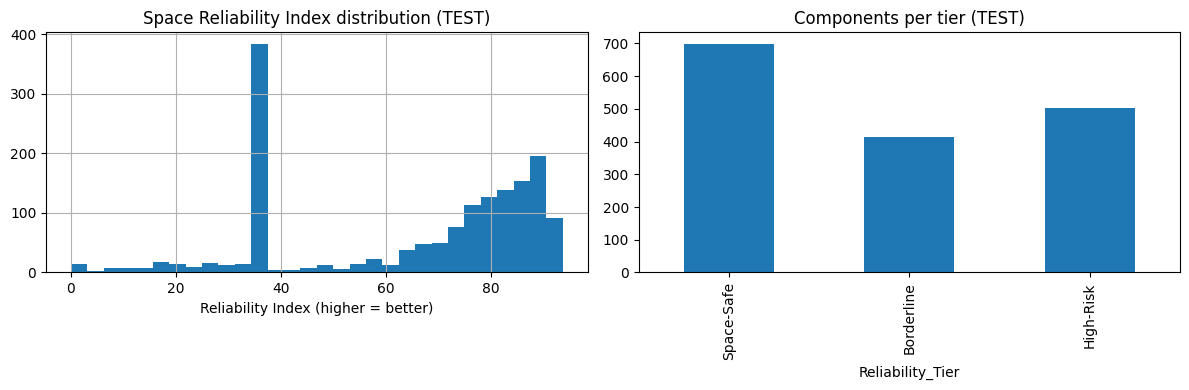

In [15]:
test_only = merged[merged['split'] == 'test']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
test_only['Space_Reliability_Index'].hist(bins=30, ax=axes[0])
axes[0].set_title('Space Reliability Index distribution (TEST)')
axes[0].set_xlabel('Reliability Index (higher = better)')

test_only['Reliability_Tier'].value_counts().reindex(['Space-Safe','Borderline','High-Risk']).plot(kind='bar', ax=axes[1])
axes[1].set_title('Components per tier (TEST)')
plt.tight_layout()
plt.show()

## Final output table

In [16]:
final_cols = [
    'Component_ID', 'Batch_ID', 'Part_Type', 'Proxy_Stress', 'split',
    'Anomaly_Risk_Score', 'Predicted_Drift_Score', 'Uncertainty_Score', 'Slope_Reject_Flag',
    'Space_Risk_Score', 'Space_Reliability_Index', 'Reliability_Tier',
    'Explainability_Reason', 'Label', 'Traditional_Test_Result',
]
final = merged[final_cols].sort_values('Space_Risk_Score', ascending=False)
final.head(10)

,Component_ID,Batch_ID,Part_Type,Proxy_Stress,split,Anomaly_Risk_Score,Predicted_Drift_Score,Uncertainty_Score,Slope_Reject_Flag,Space_Risk_Score,Space_Reliability_Index,Reliability_Tier,Explainability_Reason,Label,Traditional_Test_Result
6748,C1739,ISRO-SCL-250512-19,Op-Amp IC,Thermal-High,val,100.0,100.0,100.0,True,100.0,0.0,High-Risk,Not computed - SHAP explanations are bounded t...,Fail,Fail
3443,C5793,ISRO-SCL-250407-14,MOSFET,Cycling-Medium,train,100.0,100.0,100.0,True,100.0,0.0,High-Risk,Not computed - SHAP explanations are bounded t...,Fail,Fail
5682,C9192,ISRO-SCL-250317-11,Voltage Regulator IC,Radiation-Low,train,100.0,100.0,100.0,True,100.0,0.0,High-Risk,Not computed - SHAP explanations are bounded t...,Fail,Fail
9538,C7615,ISRO-SCL-250331-13,Voltage Regulator IC,Radiation-Low,test,100.0,100.0,100.0,True,100.0,0.0,High-Risk,High-Risk. [SHAP] Predicted Leakage 168h drift...,Fail,Fail
2606,C4484,ISRO-SCL-250414-15,Digital Logic IC,Thermal-High,train,100.0,100.0,100.0,True,100.0,0.0,High-Risk,Not computed - SHAP explanations are bounded t...,Fail,Fail
4494,C7381,ISRO-SCL-250407-14,MOSFET,Cycling-Medium,train,100.0,100.0,100.0,True,100.0,0.0,High-Risk,Not computed - SHAP explanations are bounded t...,Fail,Fail
9494,C7391,ISRO-SCL-250120-03,Op-Amp IC,Cycling-Medium,test,100.0,100.0,100.0,True,100.0,0.0,High-Risk,High-Risk. [SHAP] Predicted Leakage 168h drift...,Fail,Fail
3834,C6382,ISRO-SCL-250414-15,Digital Logic IC,Radiation-Low,train,100.0,100.0,100.0,True,100.0,0.0,High-Risk,Not computed - SHAP explanations are bounded t...,Fail,Fail
2184,C3862,ISRO-SCL-250407-14,MOSFET,Thermal-High,train,100.0,100.0,100.0,True,100.0,0.0,High-Risk,Not computed - SHAP explanations are bounded t...,Fail,Fail
2929,C4972,ISRO-SCL-250414-15,Digital Logic IC,Thermal-High,train,100.0,100.0,100.0,True,100.0,0.0,High-Risk,Not computed - SHAP explanations are bounded t...,Fail,Fail


In [17]:
final.to_csv('space_reliability_index.csv', index=False)
print(f'saved {len(final)} rows to space_reliability_index.csv (now tagged with a `split` column)')

saved 10000 rows to space_reliability_index.csv (now tagged with a `split` column)
